In [21]:
# 0. importing related libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [22]:
# 1. loading data

df = pd.read_csv("Dataset_campus_wifi_Cleaned.csv")
df

,Record_ID,Timestamp_Hour,Day_of_Week,Location,Num_Connected_Devices,Bandwidth_Usage_Mbps,AP_Load_Percent,Network_Latency_ms,Packet_Loss_Rate_Percent,Signal_Strength_dBm,Retransmission_Rate_Percent,Throughput_Mbps,Active_Sessions,Channel_Utilization_Percent,Congestion_Level
0,5077,15,Friday,Cafeteria,136.904535,159.14,36.80,39.70,1.72,-55.6,2.82,137.271756,210.0,28.86,Low
1,4532,9,Monday,Library,58.567281,64.59,26.38,34.90,1.22,-47.2,2.06,52.816405,80.0,22.63,Low
2,1498,20,Wednesday,Lecture_Hall_1,5.000000,5.00,2.73,14.90,0.15,-40.7,0.29,4.606722,30.0,5.91,Low
3,5454,21,Tuesday,Hostel_B,59.546069,43.90,19.00,31.24,1.04,-43.2,NaN,39.062429,88.0,14.41,Low
4,5512,7,Thursday,Lab_Block_B,50.213885,46.81,13.75,31.10,0.62,-48.3,1.70,43.310416,40.0,7.15,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5504,2769,6,Thursday,Admin_Block,20.700667,5.00,6.24,22.80,0.53,-42.9,0.83,4.887468,30.0,9.34,Low
5505,2738,19,Tuesday,Admin_Block,41.242511,50.04,8.45,18.40,1.66,-44.6,2.61,39.449502,45.0,11.62,Low
5506,4241,22,Friday,Lecture_Hall_1,6.874638,5.00,2.14,20.60,0.26,-42.6,0.56,4.883838,5.0,0.00,Low
5507,6306,12,Tuesday,Lecture_Hall_2,161.778438,173.69,65.59,63.50,2.71,-57.5,4.10,148.431633,220.0,64.33,Low


In [23]:
# 3. Exploratory Data Analysis (EDA)

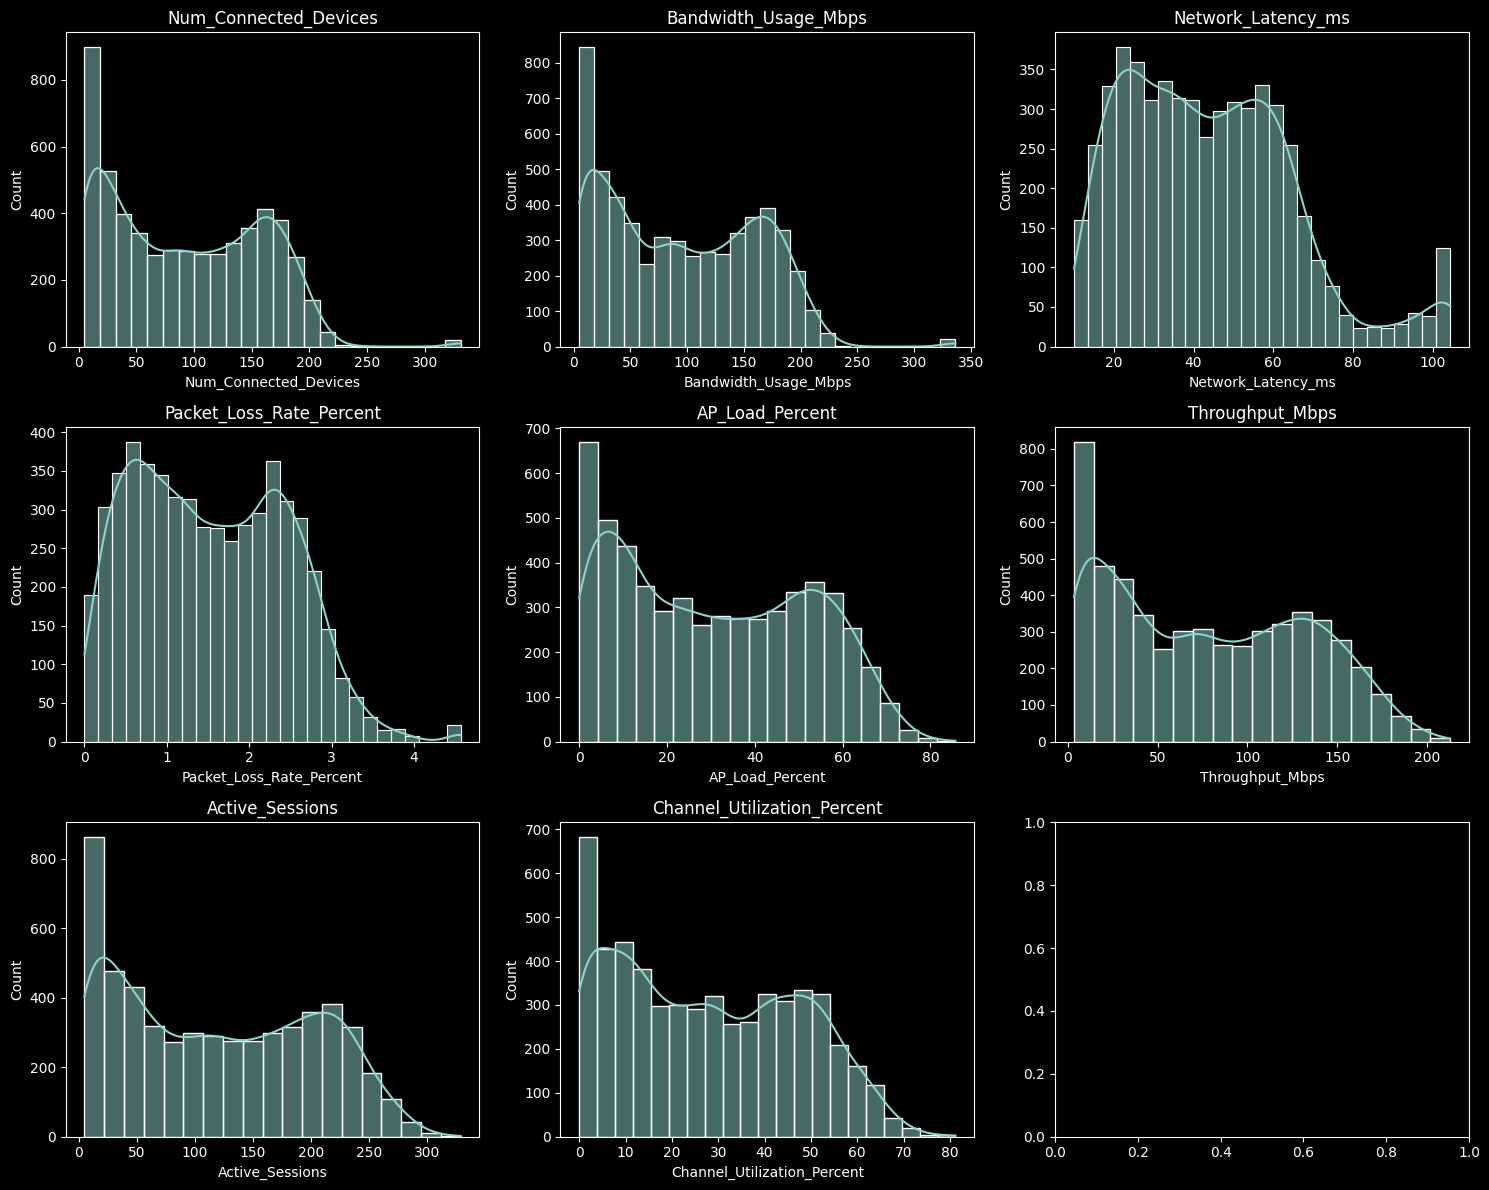

In [24]:
# 3A. Distribution plots

numeric_cols = ['Num_Connected_Devices','Bandwidth_Usage_Mbps','Network_Latency_ms',
                'Packet_Loss_Rate_Percent','AP_Load_Percent','Throughput_Mbps',
                'Active_Sessions','Channel_Utilization_Percent']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()

<Axes: xlabel='Congestion_Level', ylabel='count'>

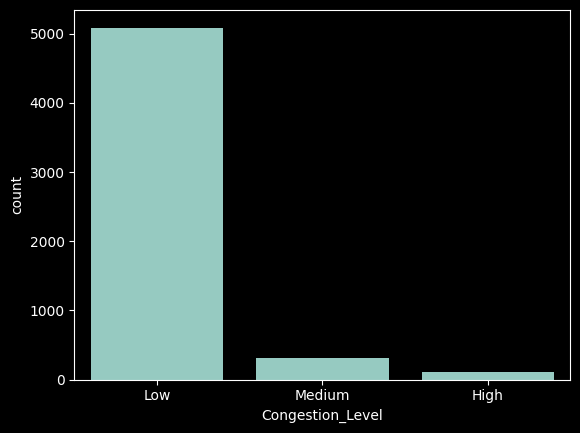

In [25]:
# 3B.  Class distribution (target)

sns.countplot(data=df, x='Congestion_Level', order=['Low','Medium','High'])

<Axes: xlabel='Timestamp_Hour', ylabel='Network_Latency_ms'>

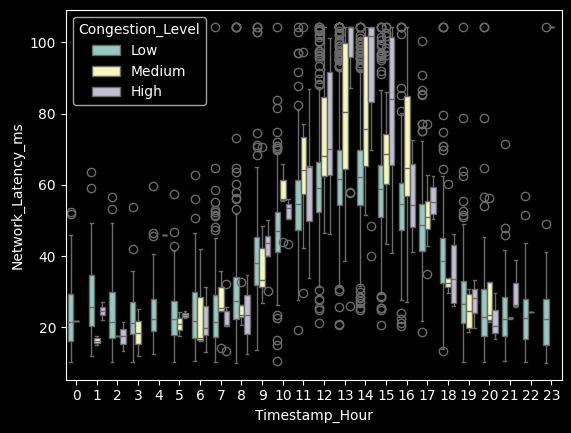

In [29]:
# 3C. Congestion by time of day

sns.boxplot(data=df, x='Timestamp_Hour', y='Network_Latency_ms', hue='Congestion_Level')
# Identifies peak hours — great for your "congestion period identification" requirement

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Cafeteria'),
  Text(1, 0, 'Library'),
  Text(2, 0, 'Lecture_Hall_1'),
  Text(3, 0, 'Hostel_B'),
  Text(4, 0, 'Lab_Block_B'),
  Text(5, 0, 'Hostel_A'),
  Text(6, 0, 'Sports_Complex'),
  Text(7, 0, 'Lecture_Hall_2'),
  Text(8, 0, 'Lab_Block_A'),
  Text(9, 0, 'Admin_Block')])

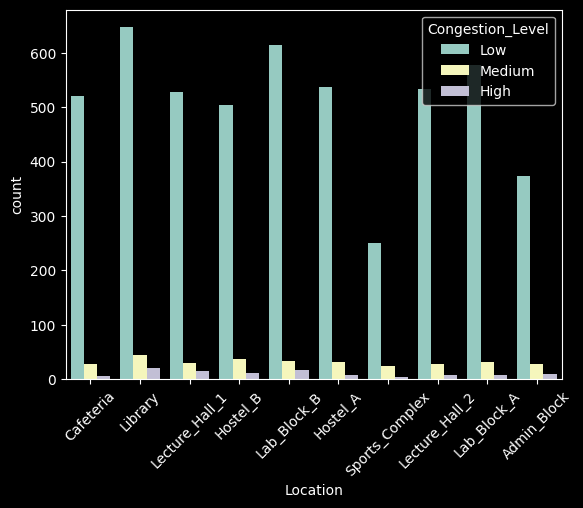

In [30]:
# 3D. Congestion by location

sns.countplot(data=df, x='Location', hue='Congestion_Level')
plt.xticks(rotation=45)

<Axes: >

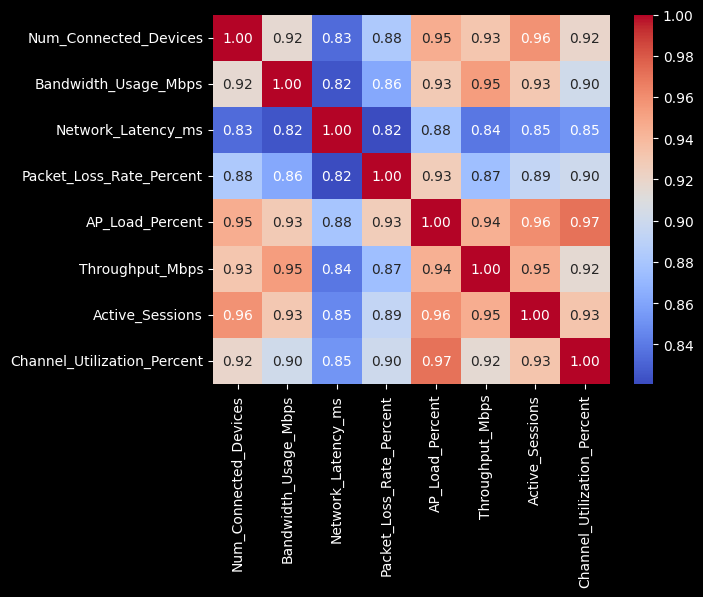

In [31]:
# 3E. Correlation heatmap

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
# Key insight: AP_Load, Devices, Bandwidth are strongly correlated

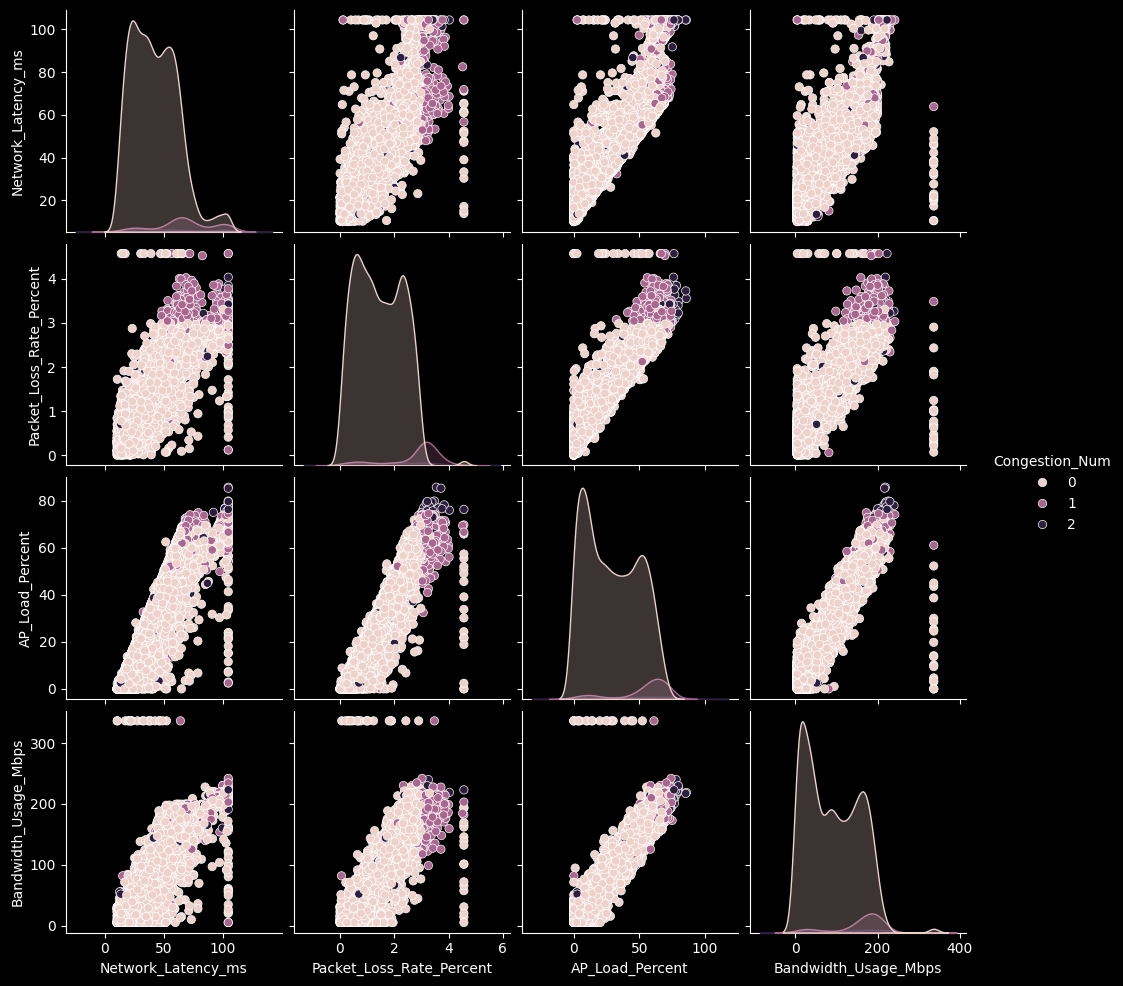

In [32]:
#3F. Pairplot (colored by congestion)

df_encoded = df.copy()
df_encoded['Congestion_Num'] = df['Congestion_Level'].map({'Low':0,'Medium':1,'High':2})
sns.pairplot(df_encoded[['Network_Latency_ms','Packet_Loss_Rate_Percent',
                          'AP_Load_Percent','Bandwidth_Usage_Mbps','Congestion_Num']],
             hue='Congestion_Num')

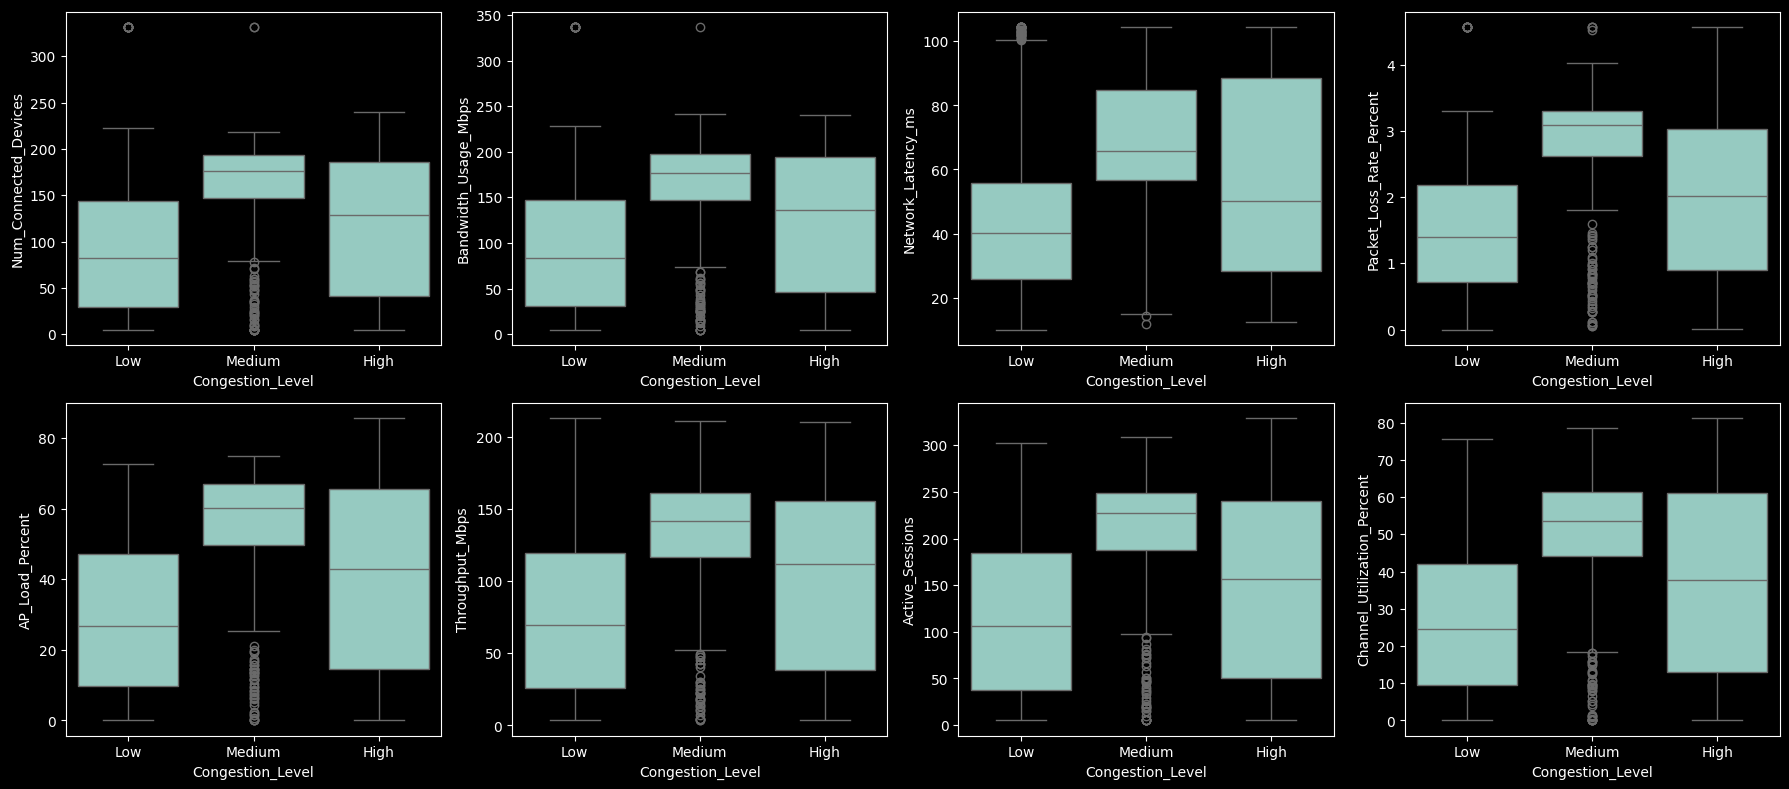

In [33]:
# 3G. Boxplots by congestion class

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(data=df, x='Congestion_Level', y=col,
                order=['Low','Medium','High'], ax=ax)
plt.tight_layout()

In [34]:
# 3H. Anomaly detection (optional bonus)

iso = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly'] = iso.fit_predict(df[numeric_cols])
df['Anomaly']
# -1 = anomaly, 1 = normal — visualize with scatter

0       1
1       1
2       1
3       1
4       1
       ..
5504    1
5505    1
5506    1
5507    1
5508    1
Name: Anomaly, Length: 5509, dtype: int64

In [36]:
# this was the Exploratory Data Analysis Section where all Statistical Analysis is being done.
# refer to next jupitor notebook : 03_feature_selection.ipynb .